# GST benchmark model

Goal: create a two-qubit GST model that is intentionally more difficult for pyGSTi's built-in optimizer than the one-qubit `Gi/Gx/Gy` model and then test it with the custom optimizer.

This notebook builds the standard two-qubit XY+CNOT gate set:

Here I am using built-in gate set named `smq2Q_XYICNOT`. There are other more complex gate-set as well for more challanging optimization. 


In [18]:
import pygsti
import warnings
import numpy as np
from scipy.linalg import LinAlgWarning
import pkgutil
import pygsti.modelpacks as modelpacks
from pygsti.modelpacks import smq2Q_XYICNOT
from pygsti.protocols import StandardGSTDesign
from pygsti.optimize import SimplerLMOptimizer

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=LinAlgWarning)
np.seterr(divide="ignore", invalid="ignore", over="ignore")

np.set_printoptions(precision=4, suppress=True)

## 2. Build the 2-qubit GST target model

I have listed all the built-in models in PyGSTi.<br>Below cell lists all the GST gate set in PyGSTi. Later we can choose a difficult model as well.  

In [68]:
available_modelpacks = [
    module.name
    for module in pkgutil.iter_modules(modelpacks.__path__)
    if not module.name.startswith("_")
]

available_modelpacks

['legacy',
 'smq1Q_XY',
 'smq1Q_XYI',
 'smq1Q_XYZI',
 'smq1Q_XZ',
 'smq1Q_Xpi2_rpe',
 'smq1Q_Ypi2_rpe',
 'smq1Q_ZN',
 'smq1Q_pi4_pi2_XZ',
 'smq2Q_XXII',
 'smq2Q_XXII_condensed',
 'smq2Q_XXYYII',
 'smq2Q_XXYYII_condensed',
 'smq2Q_XY',
 'smq2Q_XYCNOT',
 'smq2Q_XYCPHASE',
 'smq2Q_XYI',
 'smq2Q_XYI1',
 'smq2Q_XYI2',
 'smq2Q_XYICNOT',
 'smq2Q_XYICPHASE',
 'smq2Q_XYXX',
 'smq2Q_XYZICNOT',
 'smq2Q_XYZZ',
 'stdtarget']

In [4]:
def build_two_qubit_target_model():
    return smq2Q_XYICNOT.target_model(), "pygsti.modelpacks.smq2Q_XYICNOT.target_model()", smq2Q_XYICNOT
        
target_model, construction_method, modelpack = build_two_qubit_target_model()
processor_spec = modelpack.processor_spec() if modelpack is not None and hasattr(modelpack, "processor_spec") else None
print("Built target model using:", construction_method)
print("Processor spec:", type(processor_spec) if processor_spec is not None else None)
print(type(target_model))


Built target model using: pygsti.modelpacks.smq2Q_XYICNOT.target_model()
Processor spec: <class 'pygsti.processors.processorspec.QubitProcessorSpec'>
<class 'pygsti.models.explicitmodel.ExplicitOpModel'>


In [11]:
print("Operations in model:")

for label, op in target_model.operations.items():
    matrix = np.asarray(op.to_dense(), dtype=float)
    print("\nOperation:", label)
    print("Type:", type(op))
    print("Matrix shape:", matrix.shape)
    print(matrix)

Operations in model:

Operation: []
Type: <class 'pygsti.modelmembers.operations.fullarbitraryop.FullArbitraryOp'>
Matrix shape: (16, 16)
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]

Operation: Gxpi2:1
Type: <class 'pygsti.mode

In [12]:
print("State preparations:")

for label, prep in target_model.preps.items():
    vector = np.asarray(prep.to_dense(), dtype=float)
    print("\nPrep:", label)
    print("Type:", type(prep))
    print("Vector shape:", vector.shape)
    print(vector)

State preparations:

Prep: rho0
Type: <class 'pygsti.modelmembers.states.fullstate.FullState'>
Vector shape: (16,)
[0.5 0.  0.  0.5 0.  0.  0.  0.  0.  0.  0.  0.  0.5 0.  0.  0.5]


In [13]:
print("POVMs:")

for povm_label, povm in target_model.povms.items():
    print("\nPOVM:", povm_label)
    print("Type:", type(povm))
    print("Outcomes:", list(povm.keys()))

    for outcome_label, effect in povm.items():
        vector = np.asarray(effect.to_dense(), dtype=float)
        print("\nOutcome:", outcome_label)
        print("Effect type:", type(effect))
        print("Effect vector shape:", vector.shape)
        print(vector)

POVMs:

POVM: Mdefault
Type: <class 'pygsti.modelmembers.povms.unconstrainedpovm.UnconstrainedPOVM'>
Outcomes: ['00', '01', '10', '11']

Outcome: 00
Effect type: <class 'pygsti.modelmembers.povms.fulleffect.FullPOVMEffect'>
Effect vector shape: (16,)
[0.5 0.  0.  0.5 0.  0.  0.  0.  0.  0.  0.  0.  0.5 0.  0.  0.5]

Outcome: 01
Effect type: <class 'pygsti.modelmembers.povms.fulleffect.FullPOVMEffect'>
Effect vector shape: (16,)
[ 0.5  0.   0.  -0.5  0.   0.   0.   0.   0.   0.   0.   0.   0.5  0.
  0.  -0.5]

Outcome: 10
Effect type: <class 'pygsti.modelmembers.povms.fulleffect.FullPOVMEffect'>
Effect vector shape: (16,)
[ 0.5  0.   0.   0.5  0.   0.   0.   0.   0.   0.   0.   0.  -0.5  0.
  0.  -0.5]

Outcome: 11
Effect type: <class 'pygsti.modelmembers.povms.fulleffect.FullPOVMEffect'>
Effect vector shape: (16,)
[ 0.5  0.   0.  -0.5  0.   0.   0.   0.   0.   0.   0.   0.  -0.5  0.
  0.   0.5]


In [17]:
theta = target_model.to_vector()

print("Parameter vector shape:", theta.shape)
print(theta)

Parameter vector shape: (1616,)
[0.5 0.  0.  ... 0.  0.  0. ]


#### How do we get number of parameters (thetas) ?<br>

total parameters = germs dimensions * number of germs + prep vector dimension + measurement vectors basis (not fiducial) * dimension 

6 operation matrices x 16 x 16 = 1536 <br>
1 prep vector x 16 = 16 <br>
4 measurement effect vectors x 16 = 64 <br>

total parameters = 1536 + 16 + 64 = 1616

## 3. Fiducials and germs

The general flow for GST is: <br>

rho --> prep fiducial --> (germ)<sup>L</sup> --> measurement fiducial --> measurement vector basis

`rho` : the initial state used for the quantum circuit. This is just a single state.<br>
`prep fiducial` : operations to rotate the initial state. <br>
`germ*L` : germ implemented L times. L is selected from a user defined schedule. <br>
`measurement fiducial` : We don't just want to measure in a single basis so we rotate the basis before measuring it. <br>
`measurement vector basis` : This is the actual measurement vector basis.  

In [21]:
prep_fiducials = modelpack.prep_fiducials()
meas_fiducials = modelpack.meas_fiducials()
germs = modelpack.germs()

print("prep fiducials:", len(prep_fiducials))
print("meas fiducials:", len(meas_fiducials))
print("germs:", len(germs))

prep fiducials: 16
meas fiducials: 11
germs: 15


In [22]:
meas_fiducials

[Circuit({}@(0,1)),
 Circuit(Gxpi2:1@(0,1)),
 Circuit(Gypi2:1@(0,1)),
 Circuit(Gxpi2:1Gxpi2:1@(0,1)),
 Circuit(Gxpi2:0@(0,1)),
 Circuit(Gypi2:0@(0,1)),
 Circuit(Gxpi2:0Gxpi2:0@(0,1)),
 Circuit(Gxpi2:0Gxpi2:1@(0,1)),
 Circuit(Gxpi2:0Gypi2:1@(0,1)),
 Circuit(Gypi2:0Gxpi2:1@(0,1)),
 Circuit(Gypi2:0Gypi2:1@(0,1))]

## 5. Choosing a schedule

For the hard comparison against pyGSTi's built-in optimizer, we can select `max_lengths_hard` or `max_lengths_very_hard`. This increases number of circuits, i.e. the dimension of `p(x<sub>k</sub>)` and `f<sub>k</sub>` but not the number of parameters.  

In [31]:
max_lengths_hard = [1, 2, 4, 8, 16]
max_lengths_very_hard = [1, 2, 4, 8, 16, 32]

# Use this variable in later cells. Change it when you are ready.
max_lengths = max_lengths_hard

print("max_lengths:", max_lengths)


max_lengths: [1, 2, 4, 8, 16]


## 6. Build a noisy data-generation model

This gives us a controlled benchmark where the optimizer must fit a model that is not exactly the target. The first version uses pyGSTi's built-in `depolarize` helper. <br>
We can also use rotation error model instead of depolarize. Or we can use both.  

We can increase `gate_noise` and reduce `n_samples` to make the optimization problem noisier and harder.

In [32]:
gate_noise = 0.03
spam_noise = 0.01
n_samples = 1000


data_generation_model = target_model.depolarize(op_noise=0.01, spam_noise=0.005, seed=100)

# data_generation_model = target_model.rotate(max_rotate=0.02, seed=100)

# data_generation_model = target_model.rotate(max_rotate=0.04, seed=100).depolarize(
#     op_noise=0.02,
#     spam_noise=0.01,
#     seed=100,
# )

print("gate_noise:", gate_noise)
print("spam_noise:", spam_noise)
print("n_samples:", n_samples)


gate_noise: 0.03
spam_noise: 0.01
n_samples: 1000


## 7. Create a GST experiment design

The design object is the piece we want to share between pyGSTi's optimizer and your optimizer. <br>
This cell creates all the GST circuits from the individual objects we defined before like germs, prep fiducial and meas fiducial. <br>
This is where we generate the quantum circuits from the gate set. 

In [33]:
gst_design = None

design_source = processor_spec if processor_spec is not None else target_model
gst_design = StandardGSTDesign(
    design_source,
    prep_fiducials,
    meas_fiducials,
    germs,
    max_lengths,
)
print("Created StandardGSTDesign")
print(type(gst_design))



Created StandardGSTDesign
<class 'pygsti.protocols.gst.StandardGSTDesign'>


Quantum circuit can be viewed as below, 

In [34]:
circuits = list(gst_design.all_circuits_needing_data)

print("Total GST circuits:", len(circuits))

for i, circuit in enumerate(circuits[:10]):
    print(f"\nCircuit {i}:")
    print(circuit)

Total GST circuits: 8740

Circuit 0:
Qubit 0 -----
Qubit 1 -----


Circuit 1:
Qubit 0 ---|     |---
Qubit 1 ---|Gxpi2|---


Circuit 2:
Qubit 0 ---|     |---
Qubit 1 ---|Gypi2|---


Circuit 3:
Qubit 0 ---|     |-|     |---
Qubit 1 ---|Gxpi2|-|Gxpi2|---


Circuit 4:
Qubit 0 ---|Gxpi2|---
Qubit 1 ---|     |---


Circuit 5:
Qubit 0 ---|Gypi2|---
Qubit 1 ---|     |---


Circuit 6:
Qubit 0 ---|Gxpi2|-|Gxpi2|---
Qubit 1 ---|     |-|     |---


Circuit 7:
Qubit 0 ---|Gxpi2|-|     |---
Qubit 1 ---|     |-|Gxpi2|---


Circuit 8:
Qubit 0 ---|Gxpi2|-|     |---
Qubit 1 ---|     |-|Gypi2|---


Circuit 9:
Qubit 0 ---|Gypi2|-|     |---
Qubit 1 ---|     |-|Gxpi2|---



In [35]:
for i, circuit in enumerate(circuits[:10]):
    print(f"Circuit {i:3d} | length = {len(circuit):3d} ")

Circuit   0 | length =   0 
Circuit   1 | length =   1 
Circuit   2 | length =   1 
Circuit   3 | length =   2 
Circuit   4 | length =   1 
Circuit   5 | length =   1 
Circuit   6 | length =   2 
Circuit   7 | length =   2 
Circuit   8 | length =   2 
Circuit   9 | length =   2 


## 8. Create the circuit list and fake dataset

This is where we generate the data. We can use this data for the pyGSTi's built-in optimizer or export the same data to custom optimizer.


In [36]:
list_of_experiments = None
dataset = None

list_of_experiments = list(gst_design.all_circuits_needing_data)
print("Number of GST circuits:", len(list_of_experiments))

dataset = pygsti.data.simulate_data(
    data_generation_model,
    gst_design,
    num_samples=n_samples,
    sample_error="multinomial",
    seed=100,
)
print("Generated fake 2Q GST dataset")




Number of GST circuits: 8740
Generated fake 2Q GST dataset


In [50]:
for i, circuit in enumerate(list_of_experiments[:5]):
    row = dataset[circuit]

    print(f"\nCircuit {i}:")
    print(circuit)
    print("Total shots:", row.total)
    print("Counts:", dict(row.counts))
    print("Frequencies:", {outcome: row.fraction(outcome) for outcome in row.outcomes})


Circuit 0:
Qubit 0 -----
Qubit 1 -----

Total shots: 1000.0
Counts: {('00',): 998.0, ('01',): 1.0, ('10',): 0.0, ('11',): 1.0}
Frequencies: {('00',): 0.998, ('01',): 0.001, ('10',): 0.0, ('11',): 0.001}

Circuit 1:
Qubit 0 ---|     |---
Qubit 1 ---|Gxpi2|---

Total shots: 1000.0
Counts: {('00',): 481.0, ('01',): 513.0, ('10',): 0.0, ('11',): 6.0}
Frequencies: {('00',): 0.481, ('01',): 0.513, ('10',): 0.0, ('11',): 0.006}

Circuit 2:
Qubit 0 ---|     |---
Qubit 1 ---|Gypi2|---

Total shots: 1000.0
Counts: {('00',): 494.0, ('01',): 498.0, ('10',): 2.0, ('11',): 6.0}
Frequencies: {('00',): 0.494, ('01',): 0.498, ('10',): 0.002, ('11',): 0.006}

Circuit 3:
Qubit 0 ---|     |-|     |---
Qubit 1 ---|Gxpi2|-|Gxpi2|---

Total shots: 1000.0
Counts: {('00',): 4.0, ('01',): 989.0, ('10',): 4.0, ('11',): 3.0}
Frequencies: {('00',): 0.004, ('01',): 0.989, ('10',): 0.004, ('11',): 0.003}

Circuit 4:
Qubit 0 ---|Gxpi2|---
Qubit 1 ---|     |---

Total shots: 1000.0
Counts: {('00',): 493.0, ('01',): 2

## 9. Built-in pyGSTi LM optimizer baseline

This cell explicitly uses pyGSTi's built-in `SimplerLMOptimizer`, which is pyGSTi's LM-style solver for the nonlinear GST fit.

The point is to keep the exact same `target_model`, `prep_fiducials`, `meas_fiducials`, `germs`, `max_lengths`, and `dataset` for both pyGSTi's LM optimizer and your optimizer.

In [37]:
PYGSTI_BASELINE_MODES = ("full TP",)
MEMORY_LIMIT_BYTES = 3 * (1024 ** 3)

# These match pyGSTi's built-in LM-style defaults, but are explicit for comparison.
LM_MAXITER = 100
LM_MAXFEV = 100
LM_TOL = 1e-6


def make_builtin_lm_optimizer():
    return SimplerLMOptimizer(
        maxiter=LM_MAXITER,
        maxfev=LM_MAXFEV,
        tol=LM_TOL,
        init_munu="auto",
        oob_action="reject",
    )


protocol_data = pygsti.protocols.ProtocolData(gst_design, dataset)
protocol = pygsti.protocols.StandardGST(
    modes=PYGSTI_BASELINE_MODES,
    target_model=target_model,
    optimizer=make_builtin_lm_optimizer(),
    verbosity=2,
)

results = protocol.run(protocol_data, memlimit=MEMORY_LIMIT_BYTES)
print("pyGSTi StandardGST baseline completed")
print("Modes:", PYGSTI_BASELINE_MODES)
print("Optimizer: pyGSTi SimplerLMOptimizer (LM-style solver)")
print("LM settings:", {"maxiter": LM_MAXITER, "maxfev": LM_MAXFEV, "tol": LM_TOL})
print(type(results))




-- Std Practice:  Iter 1 of 1  (full TP) --: 
  --- Iterative GST: [##################################################] 100.0%  8740 circuits ---
pyGSTi StandardGST baseline completed
Modes: ('full TP',)
Optimizer: pyGSTi SimplerLMOptimizer (LM-style solver)
LM settings: {'maxiter': 100, 'maxfev': 100, 'tol': 1e-06}
<class 'pygsti.protocols.gst.ModelEstimateResults'>


## 10. Plot GST fit diagnostics

These plots compare the pyGSTi fitted model against the generated dataset:

Using estimate 'full TP' model 'stdgaugeopt'


C:\Users\athar\anaconda3\envs\Argonne_internship\Lib\site-packages\pygsti\tools\legacytools.py:38: UserWarning: The function fraction is deprecated, and may not be present in future versions of pygsti.
    Please use DataSetRow.fractions instead.
  _warnings.warn(message)


Fit model: full TP:stdgaugeopt
Number of circuits: 8740
Number of probability entries: 34960
Probability RMSE: 1.193349e-02


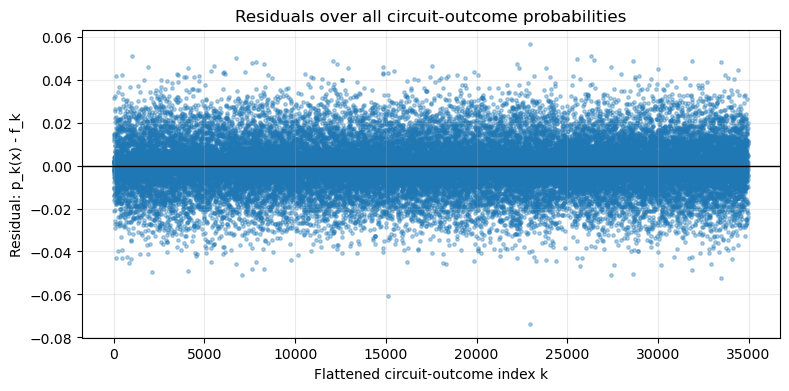

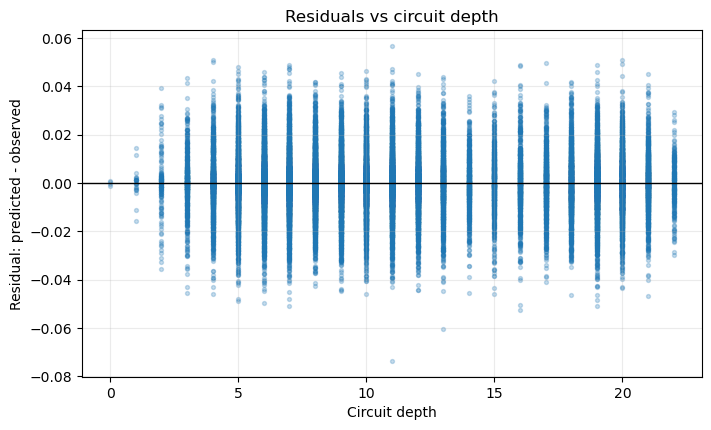

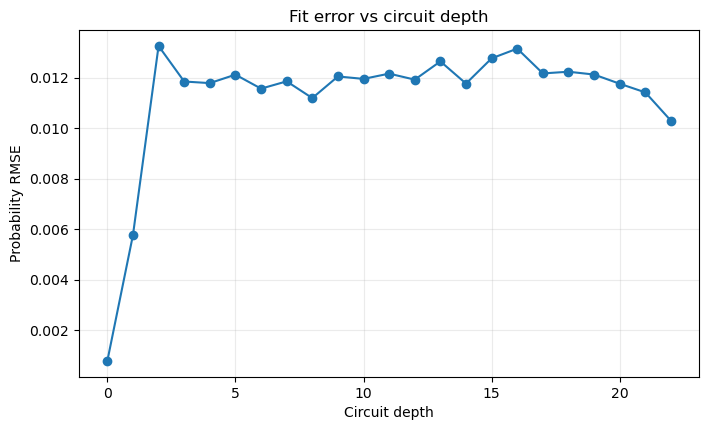

In [38]:
import math
import numpy as np
import matplotlib.pyplot as plt


def choose_fit_model(results, target_model):
    """Extract the final model from pyGSTi results, with a target-model fallback."""
    if results is None:
        print("No results object found; using target_model for plotting.")
        return target_model, "target_model"

    if not hasattr(results, "estimates") or len(results.estimates) == 0:
        print("Results has no estimates; using target_model for plotting.")
        return target_model, "target_model"

    estimate_name = list(results.estimates.keys())[-1]
    estimate = results.estimates[estimate_name]
    models = getattr(estimate, "models", {})

    for model_name in ["stdgaugeopt", "final iteration estimate", "go0", "target"]:
        if model_name in models:
            print(f"Using estimate '{estimate_name}' model '{model_name}'")
            return models[model_name], f"{estimate_name}:{model_name}"

    if len(models) > 0:
        model_name = list(models.keys())[-1]
        print(f"Using estimate '{estimate_name}' model '{model_name}'")
        return models[model_name], f"{estimate_name}:{model_name}"

    print("Could not find a model inside results; using target_model for plotting.")
    return target_model, "target_model"


def dataset_frequencies(dataset, circuit, outcomes):
    row = dataset[circuit]
    freqs = []
    for outcome in outcomes:
        try:
            freqs.append(float(row.fraction(outcome)))
        except Exception:
            total = float(row.total)
            freqs.append(float(row.counts.get(outcome, 0.0)) / total if total > 0 else np.nan)
    return np.asarray(freqs, dtype=float)


def model_probabilities_for_outcomes(model, circuit, outcomes):
    probs = model.probabilities(circuit)
    return np.asarray([float(probs.get(outcome, 0.0)) for outcome in outcomes], dtype=float)


def circuit_depth(circuit):
    try:
        return len(circuit)
    except Exception:
        return np.nan


fit_model, fit_model_name = choose_fit_model(globals().get("results", None), target_model)


observed = []
predicted = []
depths = []
outcome_labels = []

for circuit in list_of_experiments:
    row = dataset[circuit]
    outcomes = list(row.outcomes)
    obs = dataset_frequencies(dataset, circuit, outcomes)
    pred = model_probabilities_for_outcomes(fit_model, circuit, outcomes)

    observed.extend(obs)
    predicted.extend(pred)
    depths.extend([circuit_depth(circuit)] * len(outcomes))
    outcome_labels.extend(outcomes)

observed = np.asarray(observed, dtype=float)
predicted = np.asarray(predicted, dtype=float)
depths = np.asarray(depths, dtype=float)
residuals = predicted - observed
rmse = math.sqrt(np.nanmean(residuals**2))

print("Fit model:", fit_model_name)
print("Number of circuits:", len(list_of_experiments))
print("Number of probability entries:", len(observed))
print(f"Probability RMSE: {rmse:.6e}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(np.arange(len(residuals)), residuals, s=6, alpha=0.35)
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("Flattened circuit-outcome index k")
ax.set_ylabel("Residual: p_k(x) - f_k")
ax.set_title("Residuals over all circuit-outcome probabilities")
ax.grid(True, alpha=0.25)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(depths, residuals, s=8, alpha=0.25)
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("Circuit depth")
ax.set_ylabel("Residual: predicted - observed")
ax.set_title("Residuals vs circuit depth")
ax.grid(True, alpha=0.25)
plt.show()

unique_depths = np.array(sorted(set(depths[np.isfinite(depths)])), dtype=float)
rmse_by_depth = []
for depth in unique_depths:
    mask = depths == depth
    rmse_by_depth.append(math.sqrt(np.nanmean(residuals[mask] ** 2)))
rmse_by_depth = np.asarray(rmse_by_depth)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(unique_depths, rmse_by_depth, marker="o", linewidth=1.5)
ax.set_xlabel("Circuit depth")
ax.set_ylabel("Probability RMSE")
ax.set_title("Fit error vs circuit depth")
ax.grid(True, alpha=0.25)
plt.show()


## 11. PTM heatmaps

These heatmaps show the target PTM, fitted PTM, and fitted-minus-target PTM for each operation. For a two-qubit model, each operation is a `16 x 16` Pauli transfer matrix.

Plotting operation labels:
   []
   Gxpi2:1
   Gypi2:1
   Gxpi2:0
   Gypi2:0
   Gcnot:0:1


C:\Users\athar\AppData\Local\Temp\ipykernel_30808\1430556126.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


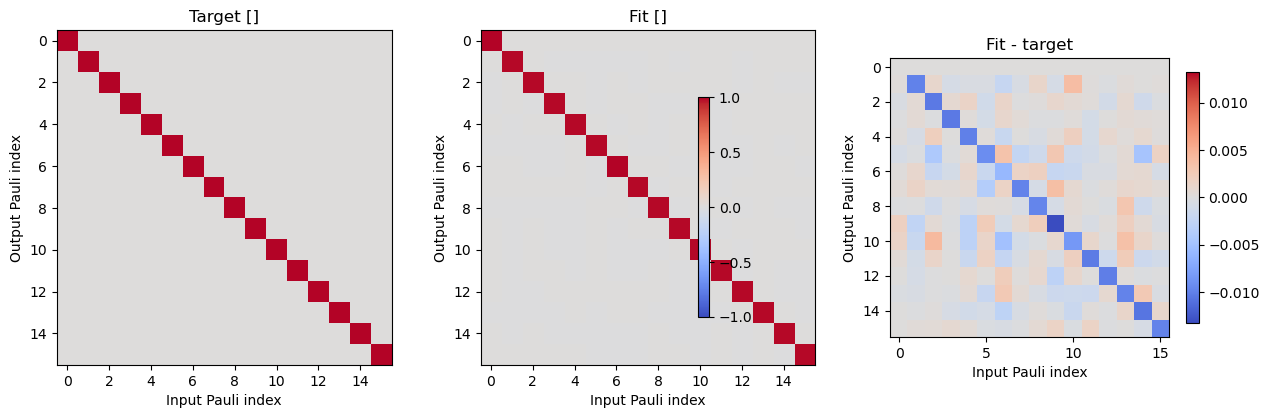

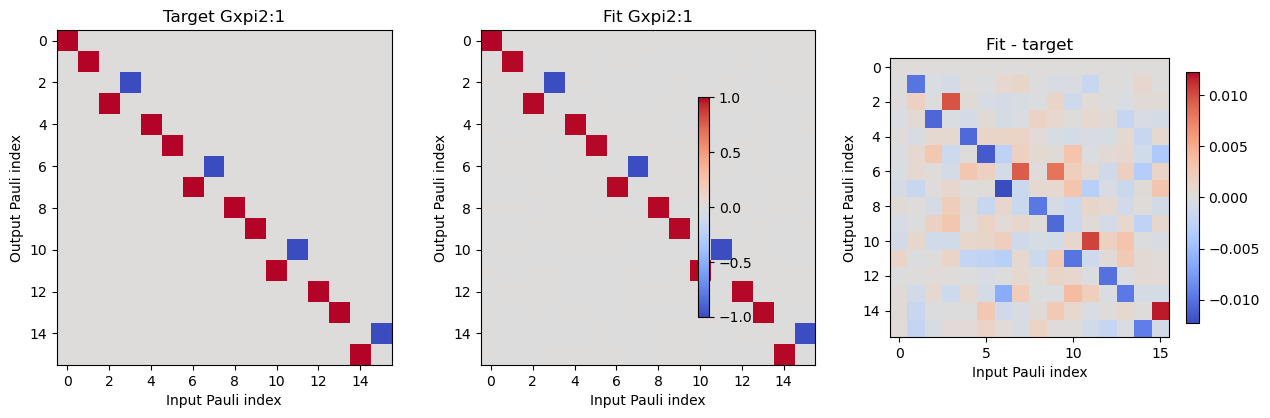

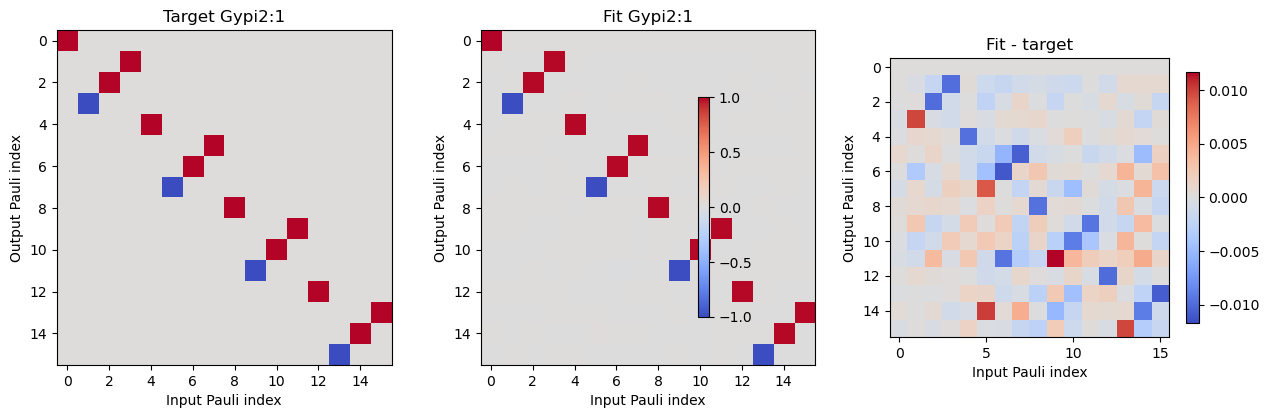

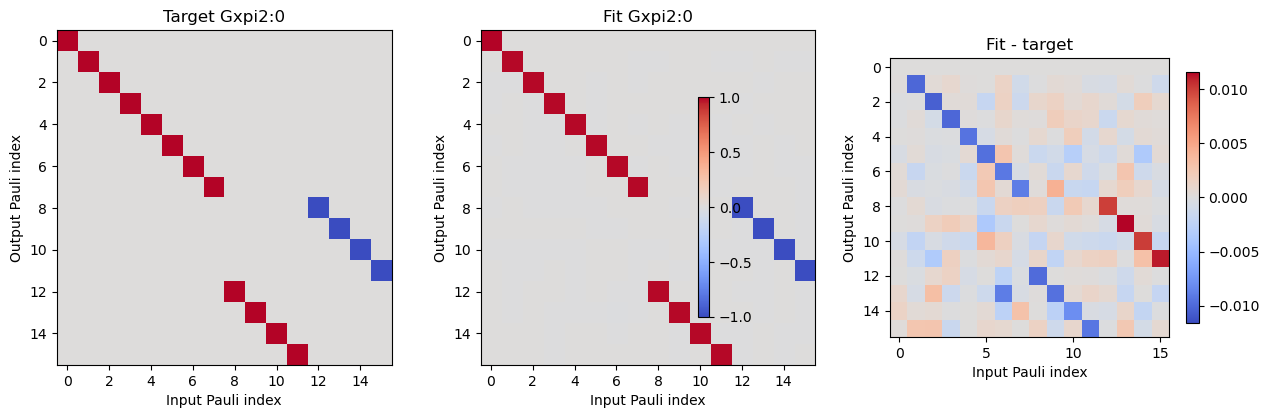

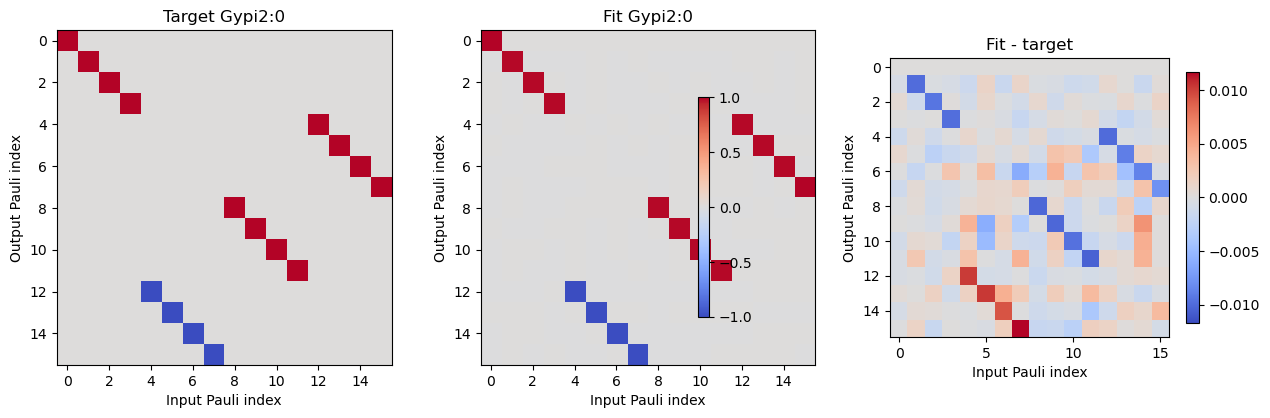

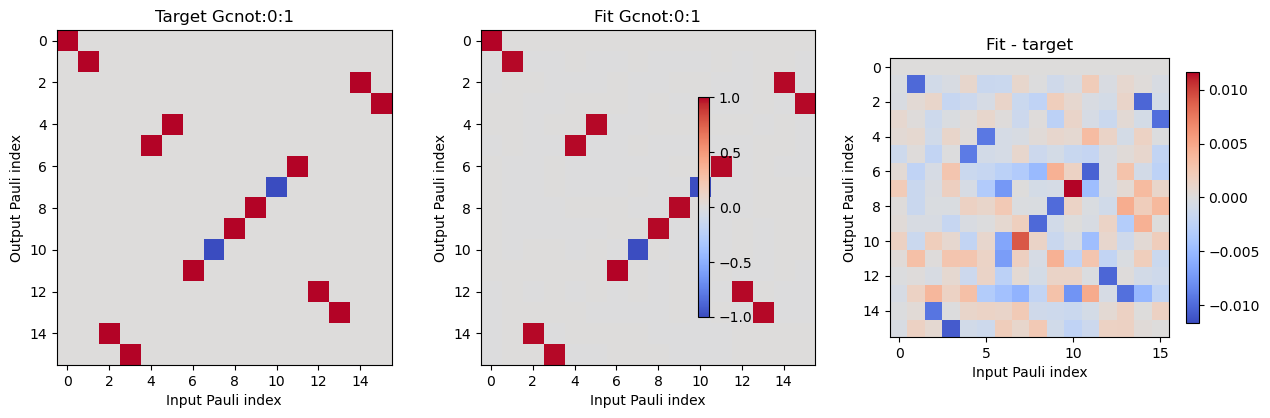

In [39]:
def op_matrix(model, label):
    ops = getattr(model, "operations", None)
    if ops is None:
        ops = getattr(model, "gates", None)
    op = ops[label]
    try:
        return np.asarray(op.to_dense(), dtype=float)
    except Exception:
        return np.asarray(op, dtype=float)


def shared_operation_labels(model_a, model_b):
    ops_a = getattr(model_a, "operations", getattr(model_a, "gates", {}))
    ops_b = getattr(model_b, "operations", getattr(model_b, "gates", {}))
    return [label for label in ops_a.keys() if label in ops_b]


labels = shared_operation_labels(target_model, fit_model)
print("Plotting operation labels:")
for label in labels:
    print("  ", label)

for label in labels:
    target_ptm = op_matrix(target_model, label)
    fit_ptm = op_matrix(fit_model, label)
    diff_ptm = fit_ptm - target_ptm
    vmax = max(np.max(np.abs(target_ptm)), np.max(np.abs(fit_ptm)), 1e-12)
    diff_vmax = max(np.max(np.abs(diff_ptm)), 1e-12)

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
    images = [
        axes[0].imshow(target_ptm, vmin=-vmax, vmax=vmax, cmap="coolwarm"),
        axes[1].imshow(fit_ptm, vmin=-vmax, vmax=vmax, cmap="coolwarm"),
        axes[2].imshow(diff_ptm, vmin=-diff_vmax, vmax=diff_vmax, cmap="coolwarm"),
    ]
    axes[0].set_title(f"Target {label}")
    axes[1].set_title(f"Fit {label}")
    axes[2].set_title("Fit - target")
    for ax in axes:
        ax.set_xlabel("Input Pauli index")
        ax.set_ylabel("Output Pauli index")
    fig.colorbar(images[0], ax=axes[:2], shrink=0.75)
    fig.colorbar(images[2], ax=axes[2], shrink=0.75)
    fig.tight_layout()
    plt.show()


Custom optimizer interface: p(x), J(x), Var[p], f, Var[f]

The variance vectors below are diagonal multinomial frequency variances: <br>
     Var[q_{c,o}] ~= q_{c,o} * (1 - q_{c,o}) / N_c <br>
For model predictions, q = p(x). For observed data, q = f. <br>
The full multinomial covariance also has off-diagonal terms within each circuit.

## 10. Functions needed for POUNDERS

In [40]:
def _model_num_params(model):
    value = model.num_params
    return value() if callable(value) else int(value)


def get_current_gst_model():
    """Return the model used by the custom optimizer interface.

    Priority:
    1. `optimizer_model`, if you set it manually
    2. `current_gst_model`, kept for backward compatibility
    3. `target_model`, the default 1616-parameter model
    4. `fit_model`, only as a fallback after LM fitting
    """
    if "optimizer_model" in globals() and optimizer_model is not None:
        return optimizer_model
    if "current_gst_model" in globals() and current_gst_model is not None:
        return current_gst_model
    if "target_model" in globals() and target_model is not None:
        return target_model
    if "fit_model" in globals() and fit_model is not None:
        return fit_model
    raise RuntimeError("Run the target-model cell first, or set current_gst_model manually.")


def _resolve_model_template(model_template=None):
    if model_template is not None:
        return model_template
    return get_current_gst_model()


def _resolve_circuits(circuits=None):
    if circuits is not None:
        return list(circuits)
    if "list_of_experiments" in globals() and list_of_experiments is not None:
        return list(list_of_experiments)
    if "gst_design" in globals() and gst_design is not None:
        return list(gst_design.all_circuits_needing_data)
    raise RuntimeError("Pass circuits or run the GST-design cell first.")


def _copy_model_at_x(x, model_template=None):
    model = _resolve_model_template(model_template).copy()
    x = np.asarray(x, dtype=float)
    if len(x) != _model_num_params(model):
        raise ValueError(
            f"x has length {len(x)}, but the model has {_model_num_params(model)} parameters."
        )
    model.from_vector(x, close=False)
    return model


def _outcomes_for_circuit(circuit, model, data_for_outcomes=None):
    if data_for_outcomes is not None:
        return list(data_for_outcomes[circuit].outcomes)
    return list(model.probabilities(circuit).keys())


def _shot_count_for_circuit(data, circuit, circuit_index, num_samples):
    if data is not None:
        return float(data[circuit].total)
    if num_samples is None:
        return None
    if np.isscalar(num_samples):
        return float(num_samples)
    return float(num_samples[circuit_index])


def gst_model_function(
    x,
    model_template=None,
    circuits=None,
    data_for_outcomes=None,
    num_samples=None,
    return_labels=False,
):

    model = _copy_model_at_x(x, model_template)
    circuits = _resolve_circuits(circuits)

    probabilities_by_circuit = model.bulk_probabilities(circuits)
    derivatives_by_circuit = model.sim.bulk_dprobs(circuits)

    p_values = []
    jacobian_rows = []
    var_p_values = []
    labels = []

    for circuit_index, circuit in enumerate(circuits):
        outcomes = _outcomes_for_circuit(circuit, model, data_for_outcomes)
        probabilities = probabilities_by_circuit[circuit]
        derivatives = derivatives_by_circuit[circuit]
        shots = _shot_count_for_circuit(data_for_outcomes, circuit, circuit_index, num_samples)

        for outcome in outcomes:
            p = float(probabilities.get(outcome, 0.0))
            p_clipped = min(max(p, 0.0), 1.0)
            p_values.append(p)
            jacobian_rows.append(np.asarray(derivatives[outcome], dtype=float))
            var_p_values.append(p_clipped * (1.0 - p_clipped) / shots if shots else 0.0)
            labels.append((circuit, outcome))

    p_vector = np.asarray(p_values, dtype=float)
    jacobian = np.vstack(jacobian_rows) if jacobian_rows else np.empty((0, _model_num_params(model)))
    var_p = np.asarray(var_p_values, dtype=float)

    if return_labels:
        return p_vector, jacobian, var_p, labels
    return p_vector, jacobian, var_p


def gst_data_function(data=None, circuits=None, return_labels=False):
    """Return observed frequencies f and diagonal Var[f] from a pyGSTi DataSet."""
    if data is None:
        if "dataset" not in globals() or dataset is None:
            raise RuntimeError("Pass data or run the dataset cell first.")
        data = dataset

    circuits = _resolve_circuits(circuits)
    f_values = []
    var_f_values = []
    labels = []

    for circuit in circuits:
        row = data[circuit]
        total = float(row.total)
        fractions = row.fractions

        for outcome in row.outcomes:
            f = float(fractions.get(outcome, 0.0))
            f_clipped = min(max(f, 0.0), 1.0)
            f_values.append(f)
            var_f_values.append(f_clipped * (1.0 - f_clipped) / total if total > 0 else np.nan)
            labels.append((circuit, outcome))

    f_vector = np.asarray(f_values, dtype=float)
    var_f = np.asarray(var_f_values, dtype=float)

    if return_labels:
        return f_vector, var_f, labels
    return f_vector, var_f


In [43]:
optimizer_model = target_model
# optimizer_model = fit_model

active_model = get_current_gst_model()
x_current = active_model.to_vector()

# Use all GST circuits here. 
gst_circuits = list_of_experiments

px_k, jac_px_k, var_px_k, p_labels_demo = gst_model_function(
    x_current,
    model_template=active_model,
    circuits=gst_circuits,
    data_for_outcomes=dataset,
    return_labels=True,
)
f_k, var_f_k, f_labels_demo = gst_data_function(
    dataset,
    circuits=gst_circuits,
    return_labels=True,
)

print("Current model type:", type(active_model))
print("Current parameter vector shape:", x_current.shape)
print("px_k shape:", px_k.shape)
print("jac_px_k shape:", jac_px_k.shape)
print("var_px_k shape:", var_px_k.shape)
print("f_k shape:", f_k.shape)
print("var_f_k shape:", var_f_k.shape)

Current model type: <class 'pygsti.models.explicitmodel.ExplicitOpModel'>
Current parameter vector shape: (1616,)
px_k shape: (34960,)
jac_px_k shape: (34960, 1616)
var_px_k shape: (34960,)
f_k shape: (34960,)
var_f_k shape: (34960,)
